In [ ]:
#importing the data set in this code cell and printing the top 5 rows
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv" #the data set is the a messy data set taken on purpose to serve the purpuose of project1

df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
print("Rows and Columns:", df.shape)

df.info()


Rows and Columns: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
import numpy as np

#we already have a data set with missing values but to fulfill the purpose of the projecct i am intentionally mmaking the data messier but we create a copy

dirty_df=df.copy() #we have copied the original data set into "dirty_df"

dirty_df=pd.concat([dirty_df,dirty_df.iloc[:10]],ignore_index=True)# here we have added more duplicates to the existing "dirty_df" dataset

#intentionally changing values and setting invalide values here, basically by using .loc i am acessing the fifth row of the age column and changing that value to -10
dirty_df.loc[5,"Age"]=-10

dirty_df.loc[15, 'Age'] = 250

#here we are doing the same thing just the difference being here we are changing the value to a null value
dirty_df.loc[3, 'Name'] = np.nan
dirty_df.loc[20, 'Fare'] = -500

dirty_df.loc[50:60, 'Embarked'] = np.nan

dirty_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,NaN,female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
!pip install plotly seaborn

In [ ]:
#here we are importing libraries for visualisation in order to create charts,visualise data quality problems
import plotly.express as px #as it helps in creating beautiful, interactivve charts
import matplotlib.pyplot as plt #helps in creating heatmaps, base plotting
import seaborn as sns #heatmap,distributions & correlation analysis

In [ ]:

missing_values = dirty_df.isnull().sum() #gives us the count of missing values "NAN" in the data for every column and .sum() adds the number of missing values an gives us the total number

#to find the percentage of missing values
missing_percentage = (missing_values / len(dirty_df)) * 100

#creating summary table
missing_df = pd.DataFrame({
    'Column': dirty_df.columns,
    'Missing Values': missing_values.values,
    'Missing Percentage': missing_percentage.values
})

missing_df

,Column,Missing Values,Missing Percentage
0,PassengerId,0,0.000000
1,Survived,0,0.000000
2,Pclass,0,0.000000
3,Name,1,0.110988
4,Sex,0,0.000000
5,Age,177,19.644839
6,SibSp,0,0.000000
7,Parch,0,0.000000
8,Ticket,0,0.000000
9,Fare,0,0.000000


In [ ]:
#visusalise the missing values

fig=px.bar(
    missing_df,
    x="Column",
    y="Missing Percentage",
    title="Missing values percentage"
)

fig.show()

In [ ]:
#DQ second metric-CONSISTENCY which means s the data logically uniform and non-repetitive
duplicate_count=dirty_df.duplicated().sum()
print("Duplicate Rows:",duplicate_count)


Duplicate Rows: 8


In [ ]:
#detect invalide ages- this is accuracy metric of DQ
invalid_age=dirty_df[(dirty_df['Age']<0)|(dirty_df['Age']>100)]
print("Invalid Age Rows:")
print(invalid_age)


Invalid Age Rows:
    PassengerId  Survived  Pclass                              Name     Sex  \
5             6         0       3                  Moran, Mr. James    male   
15           16         1       2  Hewlett, Mrs. (Mary D Kingcome)   female   

      Age  SibSp  Parch  Ticket     Fare Cabin Embarked  
5   -10.0      0      0  330877   8.4583   NaN        Q  
15  250.0      0      0  248706  16.0000   NaN        S  


In [ ]:
#detect invalid fare
invalid_fare=dirty_df[(dirty_df["Fare"]<0)]
print("Invalid fare:",invalid_fare)

Invalid fare:     PassengerId  Survived  Pclass                  Name   Sex   Age  SibSp  \
20           21         0       2  Fynney, Mr. Joseph J  male  35.0      0   

    Parch  Ticket   Fare Cabin Embarked  
20      0  239865 -500.0   NaN        S  


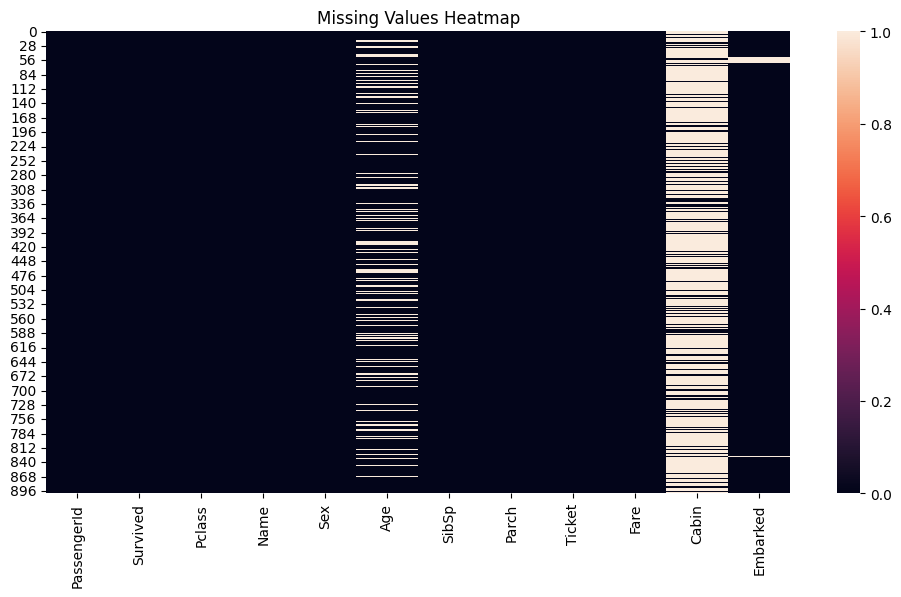

In [ ]:
#heatmap for the missing values, a heatmap is a colorbased representation of data

plt.figure(figsize=(12,6))

sns.heatmap(
    dirty_df.isnull(),
    cbar=True
)

plt.title("Missing Values Heatmap")

plt.show()

In [ ]:
fig = px.histogram(
    dirty_df,
    x='Age',
    title='Age Distribution',
    nbins=30
)

fig.show()

In [ ]:
fig = px.box(
    dirty_df,
    y='Fare',
    title='Fare Distribution'
)

fig.show()

In [ ]:
import numpy as np
total_cells=np.prod(dirty_df.shape)
total_missing=missing_values.sum()
complete_score=((total_cells-total_missing)/total_cells)*100 #this is the ercentage of value of completeness that means this many datasets have no null values but valid values
duplicate_penalty=(duplicate_count/len(dirty_df))*100  #this is the percentage of duplicate rows out of the whole data set
quality_score=(complete_score-duplicate_penalty)
quality_score = round(max(0, quality_score),2)
print("Overall Data Quality Score:", quality_score)

Overall Data Quality Score: 90.93


In [ ]:
#here we are
#checking every row,
#finding rows containing missing values,
#extracting problematic records,
#displaying first 10 bad rows.
problematic_rows = dirty_df[
    dirty_df.isnull().any(axis=1)
]

problematic_rows.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,NaN,female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,-10.0,0,0,330877,8.4583,NaN,Q


In [ ]:
dirty_df.to_csv(
    "dirty_titanic_dataset.csv",
    index=False
)

In [ ]:
!ls

dirty_titanic_dataset.csv  sample_data


# Executive Summary

## Objective
The goal of this project was to analyze and measure data quality dimensions including completeness, consistency, and accuracy using Python-based automated checks.

## Key Findings
- Missing values were detected in Age, Cabin, and Embarked columns.
- Duplicate records were intentionally introduced and successfully detected.
- Invalid ages and negative fare values were identified.
- Overall dataset quality score was calculated.

## Techniques Used
- Missing value analysis
- Duplicate detection
- Data validation rules
- Data visualization
- Heatmap analysis

## Tools & Libraries
- Python
- Pandas
- Plotly
- Seaborn
- Matplotlib

In [ ]:
!pip install streamlit pyngrok --quiet

In [ ]:
%%writefile app.py

import pandas as pd
import numpy as np
import streamlit as st
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# PAGE CONFIG
# -----------------------------

st.set_page_config(
    page_title="Data Quality Dashboard",
    layout="wide"
)

st.title("📊 Data Quality Dashboard")
st.markdown("### Titanic Dataset Quality Assessment")

# -----------------------------
# LOAD DATA
# -----------------------------

df = pd.read_csv("dirty_titanic_dataset.csv")

# -----------------------------
# METRICS
# -----------------------------

total_cells = np.prod(df.shape)

missing_values = df.isnull().sum()

total_missing = missing_values.sum()

missing_percentage = (
    missing_values / len(df)
) * 100

duplicate_count = df.duplicated().sum()

completeness_score = (
    (total_cells - total_missing)
    / total_cells
) * 100

duplicate_penalty = (
    duplicate_count / len(df)
) * 100

quality_score = round(
    max(0, completeness_score - duplicate_penalty),
    2
)

# -----------------------------
# KPI CARDS
# -----------------------------

col1, col2, col3, col4 = st.columns(4)

col1.metric(
    "Overall DQ Score",
    f"{quality_score}%"
)

col2.metric(
    "Missing Values",
    int(total_missing)
)

col3.metric(
    "Duplicate Rows",
    int(duplicate_count)
)

col4.metric(
    "Total Rows",
    len(df)
)

st.divider()

# -----------------------------
# MISSING VALUES TABLE
# -----------------------------

st.subheader("Missing Values Analysis")

missing_df = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": missing_values.values,
    "Missing Percentage": missing_percentage.values
})

st.dataframe(missing_df)

# -----------------------------
# MISSING VALUES BAR CHART
# -----------------------------

fig1 = px.bar(
    missing_df,
    x="Column",
    y="Missing Percentage",
    title="Missing Values Percentage by Column",
    color="Missing Percentage"
)

st.plotly_chart(fig1, use_container_width=True)

# -----------------------------
# HEATMAP
# -----------------------------

st.subheader("Missing Values Heatmap")

fig, ax = plt.subplots(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    ax=ax
)

st.pyplot(fig)

# -----------------------------
# AGE DISTRIBUTION
# -----------------------------

st.subheader("Age Distribution")

fig2 = px.histogram(
    df,
    x="Age",
    nbins=30,
    title="Age Distribution"
)

st.plotly_chart(fig2, use_container_width=True)

# -----------------------------
# FARE BOXPLOT
# -----------------------------

st.subheader("Fare Distribution")

fig3 = px.box(
    df,
    y="Fare",
    title="Fare Box Plot"
)

st.plotly_chart(fig3, use_container_width=True)

# -----------------------------
# INVALID AGE RECORDS
# -----------------------------

st.subheader("Invalid Age Records")

invalid_age = df[
    (df['Age'] < 0) |
    (df['Age'] > 100)
]

st.dataframe(invalid_age)

# -----------------------------
# NEGATIVE FARE RECORDS
# -----------------------------

st.subheader("Negative Fare Records")

negative_fare = df[
    df['Fare'] < 0
]

st.dataframe(negative_fare)

# -----------------------------
# PROBLEMATIC ROWS
# -----------------------------

st.subheader("Rows with Missing Values")

problematic_rows = df[
    df.isnull().any(axis=1)
]

st.dataframe(problematic_rows.head(20))

# -----------------------------
# BUSINESS SUMMARY
# -----------------------------

st.subheader("Business Insights")

st.markdown(f"""
- Overall dataset quality score is **{quality_score}%**
- Dataset contains **{total_missing} missing values**
- Duplicate records detected: **{duplicate_count}**
- Cabin column has severe incompleteness
- Invalid age values indicate data entry issues
- Negative fare values suggest corruption or validation failures
""")

Overwriting app.py


In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("3EIKmO32HDnSxPStjoy1f674FiQ_6bEfPRCkFd8qvb2E4nYqP")

In [ ]:
public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://antivirus-awaken-slingshot.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
!streamlit run app.py &



2026-05-27 06:04:48.058 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://136.117.132.106:8501

2026-05-27 06:04:53.735 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-05-27 06:04:54.480 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-05-27 06:04:54.517 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.


  Stopping...


In [37]:
from google.colab import files

files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
from google.colab import files

files.download("dirty_titanic_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>